In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay,RocCurveDisplay,roc_auc_score,precision_recall_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV,StratifiedKFold,ParameterGrid
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
import seaborn as sns
from sklearn.metrics import RocCurveDisplay
from sklearn.ensemble import IsolationForest

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("creditcard.csv")

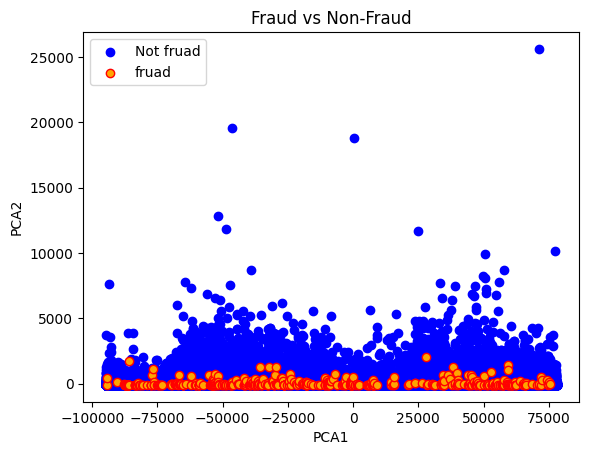

In [44]:
x = data[["Time","V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","V11","V12","V13","V14","V15","V16","V17","V18","V19","V20","V21","V22","V23","V24","V25","V26","V27","V28","Amount"]]
y = data["Class"]

# Using PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# Plot the dataset in graph
plt.scatter(x_pca[y==0,0],x_pca[y==0,1],label = 'Not fruad',c='blue')
plt.scatter(x_pca[y==1,0],x_pca[y==1,1],label = 'fruad',c='orange',edgecolors='r')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title("Fraud vs Non-Fraud")
plt.legend()
plt.show()

# Spliting data into training and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
# Creating dictionary of different models
models = {'LogisticRegression':LogisticRegression(max_iter=1000,random_state=42),
          "RandomForestClassifier":RandomForestClassifier(),
          "GradientBoostingClassifier":GradientBoostingClassifier(),
          "XGboostClassifier":XGBClassifier()}


### Plot the graph to test which model works better with smote

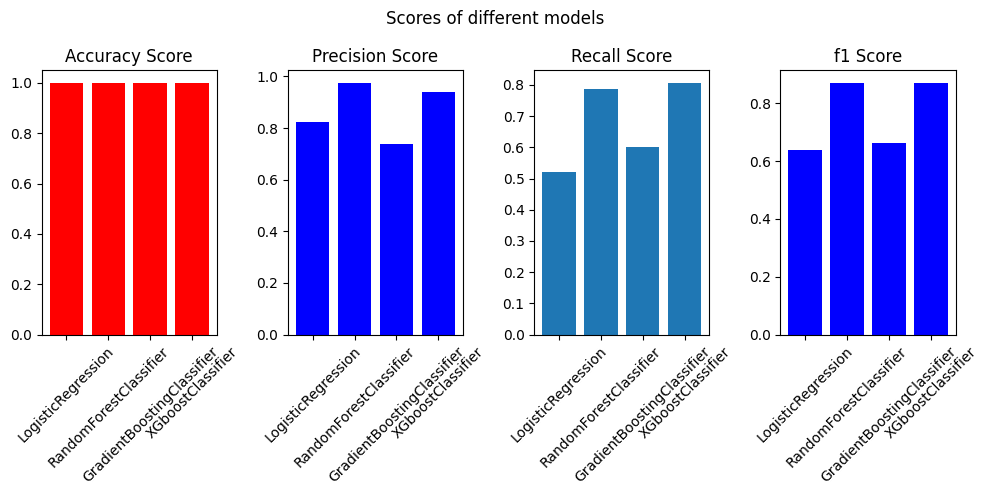

In [10]:
x = data[["Time","V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","V11","V12","V13","V14","V15","V16","V17","V18","V19","V20","V21","V22","V23","V24","V25","V26","V27","V28","Amount"]]
y = data["Class"]

# Spliting data into training and testings sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Appending all data to list
acc = []
pre = []
recall = []
f1 = []

# Different model scores
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    acc.append(accuracy_score(y_test,y_pred))
    pre.append(precision_score(y_test,y_pred))
    recall.append(recall_score(y_test,y_pred))
    f1.append(f1_score(y_test,y_pred))
position = range(len(models))
model_names = list(models.keys())

# Plot the graph of different scores of different models
fig,ax = plt.subplots(1,4,figsize = (10,5))

ax[0].bar(position,acc,color = 'red')
ax[0].set_title('Accuracy Score')
ax[0].set_xticks(position)
ax[0].set_xticklabels(model_names,rotation = 45)

ax[1].bar(position,pre,color = 'blue')
ax[1].set_title('Precision Score')
ax[1].set_xticks(position)
ax[1].set_xticklabels(model_names,rotation = 45)

ax[2].bar(position,recall)
ax[2].set_title('Recall Score')
ax[2].set_xticks(position)
ax[2].set_xticklabels(model_names,rotation = 45)

ax[3].bar(position,f1,color = 'blue')
ax[3].set_title('f1 Score')
ax[3].set_xticks(position)
ax[3].set_xticklabels(model_names,rotation = 45)

plt.suptitle('Scores of different models')
plt.tight_layout()
plt.show()

## Training model

In [ ]:
x = data[["Time","V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","V11","V12","V13","V14","V15","V16","V17","V18","V19","V20","V21","V22","V23","V24","V25","V26","V27","V28","Amount"]]
y = data["Class"]


# Split data into training and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [5]:
model = XGBClassifier()

# Hperparameter tunning
parameters = {"n_estimators":[100,200,300,400,500,600,700,800],
              "max_depth":[4,7,10],
              "learning_rate":[0.01,0.1,0.2],
              "min_child_weight":[1,2,3,4,5,6,7,8,9,10],
              "reg_alpha":[0.01,0.05,0.1],
              "reg_lambda":[1,2,3,4,5],
              "scale_pos_weight":[577]}
# Using StratifiedCV
CV = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)

# Using RandomizedSearchCV
model_cv = RandomizedSearchCV(model,param_distributions=parameters,cv = CV,n_iter=10,n_jobs=-1,scoring="f1")

In [30]:
# Hyperparameter tuning of Isolation forest
param_grid = {
    'n_estimators': [100, 200],
    'max_samples': [256, 512],
    'contamination': [0.001, 0.005, 0.01]
}

best_score = -1
best_param = None
for param in ParameterGrid(param_grid):
    iso = IsolationForest(**param,random_state=42)
    iso.fit(x_train)

    scores = iso.decision_function(x_train)
    auc = roc_auc_score(y_train,scores)
    if best_score < auc:
        best_score = auc
        best_param = param

In [ ]:
# Using best parameter in Isolation forest
iso = IsolationForest(**best_param)
iso.fit(x_train)

x_train['anomaly score'] = iso.decision_function(x_train)
x_test['anomaly score'] = iso.decision_function(x_test)

In [16]:
# Using SMOTE
smote = SMOTE(random_state=42)
x_smote,y_smote = smote.fit_resample(x_train,y_train)

In [17]:
# Fit the x_sampled and y_sampled in the model
model_cv.fit(x_smote,y_smote)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [4, 7, ...], 'min_child_weight': [1, 2, ...], 'n_estimators': [100, 200, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


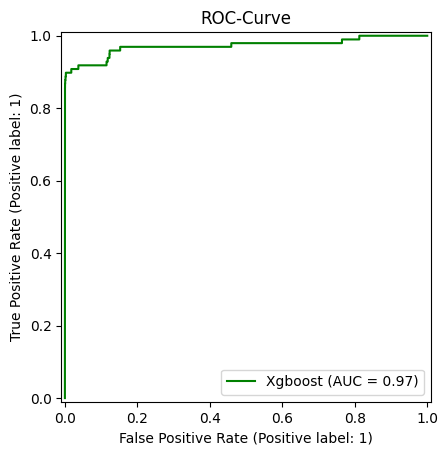

In [32]:
# Plot ROC Curve
y_prob = model_cv.predict_proba(x_test)[:,1]
RocCurveDisplay.from_predictions(y_test,y_prob,name="Xgboost",color = 'green')
plt.title("ROC-Curve")
plt.show()

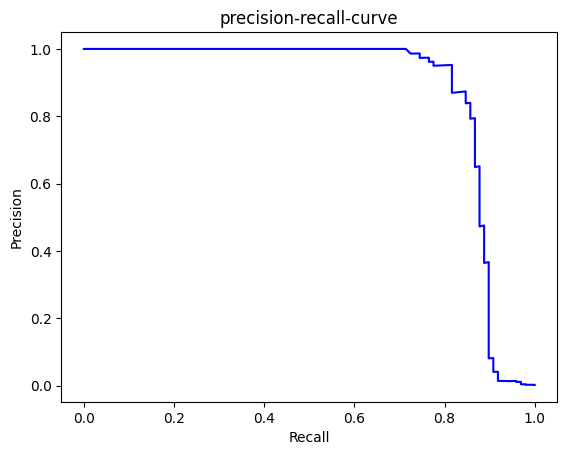

In [31]:
precision,recall,threshold = precision_recall_curve(y_test,y_prob)
plt.plot(recall,precision,color = 'blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('precision-recall-curve')
plt.show()

In [19]:
# Choosing best threshold on the basis of best f1_score
best_threshold = 0
best_f1 = 0
for threshold in np.arange(0.1,0.95,0.01):
    y_prob = model_cv.predict_proba(x_test)[:,1]
    y_pred = (y_prob > threshold).astype(int)
    f1 = f1_score(y_test,y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

In [20]:
y_prob = model_cv.predict_proba(x_test)[:,1]
y_pred = (y_prob > threshold).astype(int)

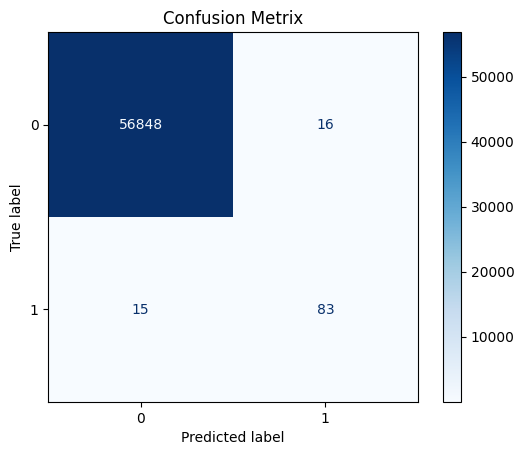

In [39]:
# Ploting confusion metrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap='Blues')
plt.title("Confusion Metrix")
plt.show()

### Recall,precision and recall matters most then accuracy 

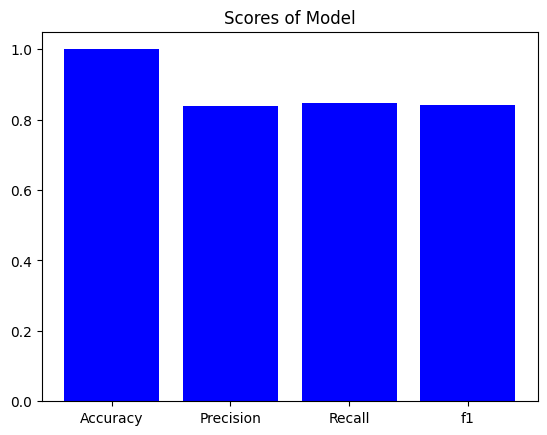

In [33]:
# Ploting the Scores of the model 
acc = accuracy_score(y_test,y_pred)
pre = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
plt.bar(["Accuracy","Precision","Recall","f1"],[acc,pre,recall,f1],color = 'blue')
plt.title("Scores of Model")
plt.show()